# 🏠 Challenge #02: House Prices — From Scratch

**Authors:** Zakariae
**Date:**  
**Time Limit:** 5 hours   
**Rules:** No scikit-learn for model building. Only NumPy, Pandas, Matplotlib.  
**Dataset:** California Housing (20,640 districts, predict median_house_value)

## Step 0: Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

In [2]:
df = pd.read_csv("data/housing.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
1,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
2,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
3,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
4,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


## Step 1: Problem Framing (30 min) ⏱️

**What am I predicting?**  
- it s a regression problem , i m trying to predict "median_house_value" which is a numerical value

**What metric defines success?**  
- MSE/MAE/R_squared

**Business context:**  
- this will help the housing market to give the best price for a house

## Step 2: EDA (45 min) ⏱️

<Axes: ylabel='Frequency'>

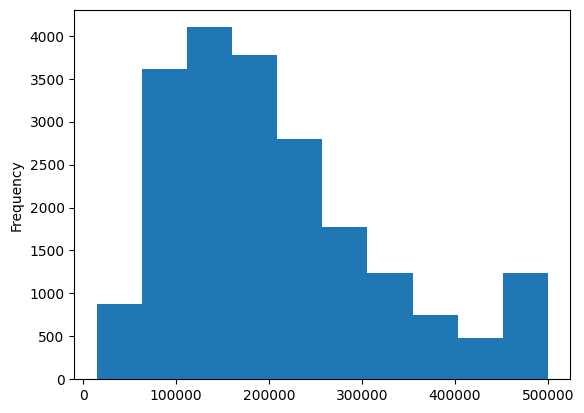

In [39]:
# Target distribution
df['median_house_value'].plot(kind='hist')


<Axes: >

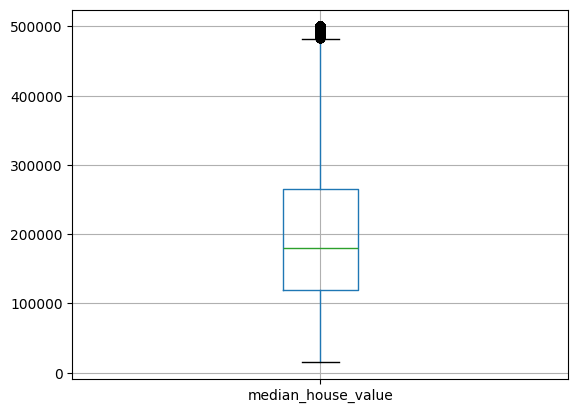

In [41]:
df.boxplot(['median_house_value'])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

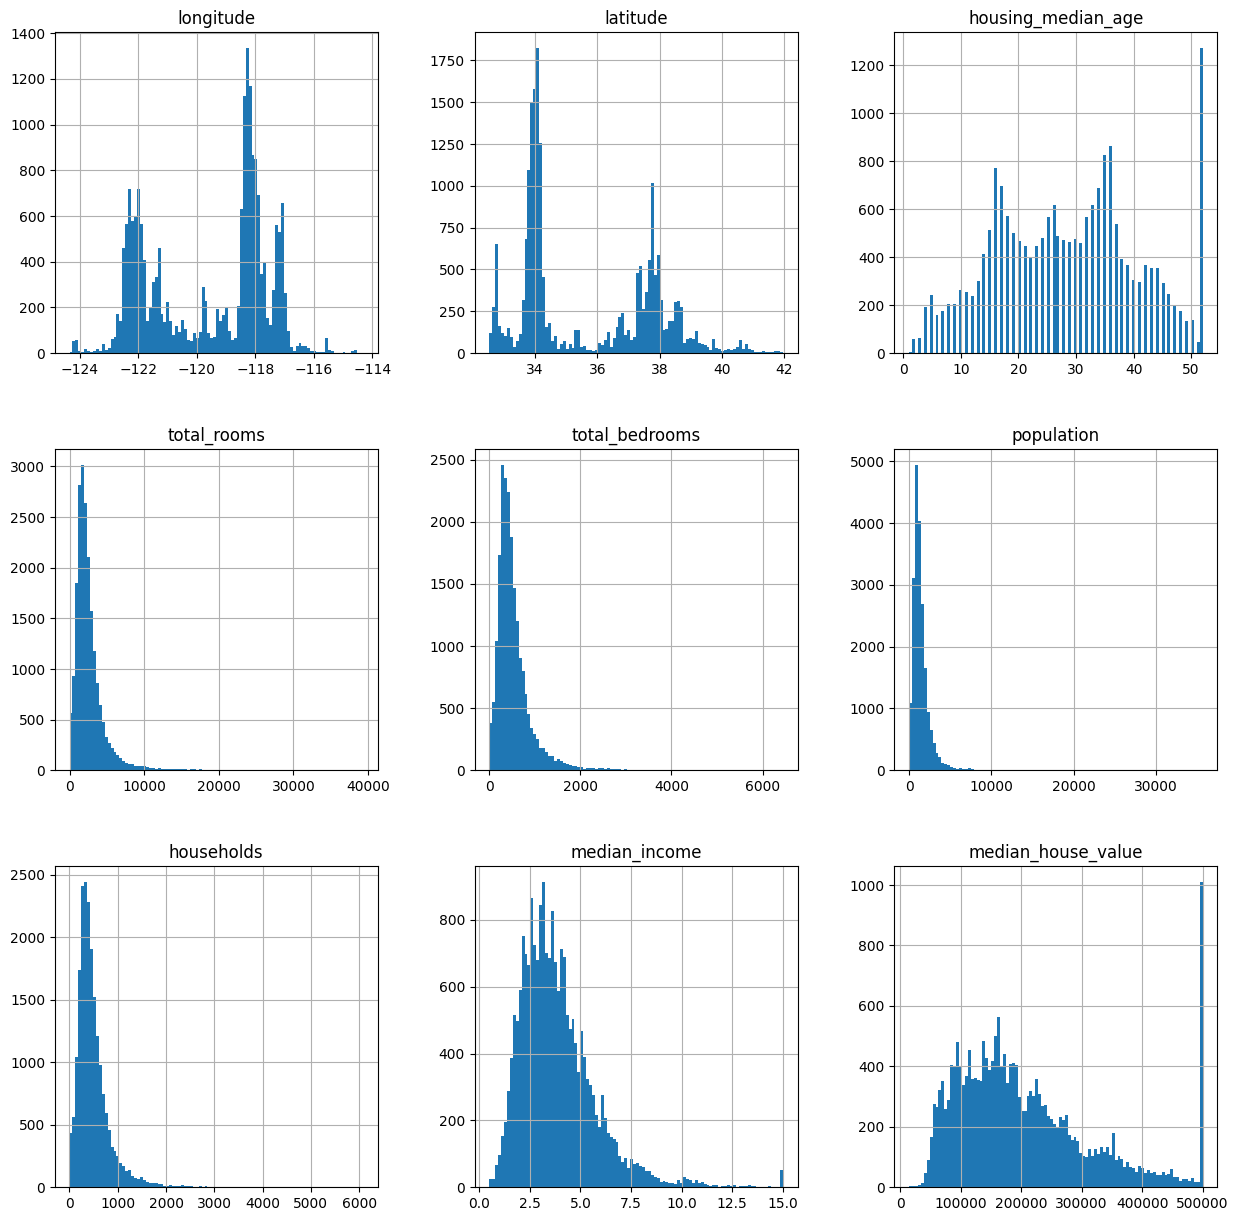

In [36]:
df.hist(bins=100, figsize=(15, 15))

In [4]:
df.info() 

# Data types : 9 float / 1 str
# Missing values: total_bedrooms(floats) 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# Numerical summary
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


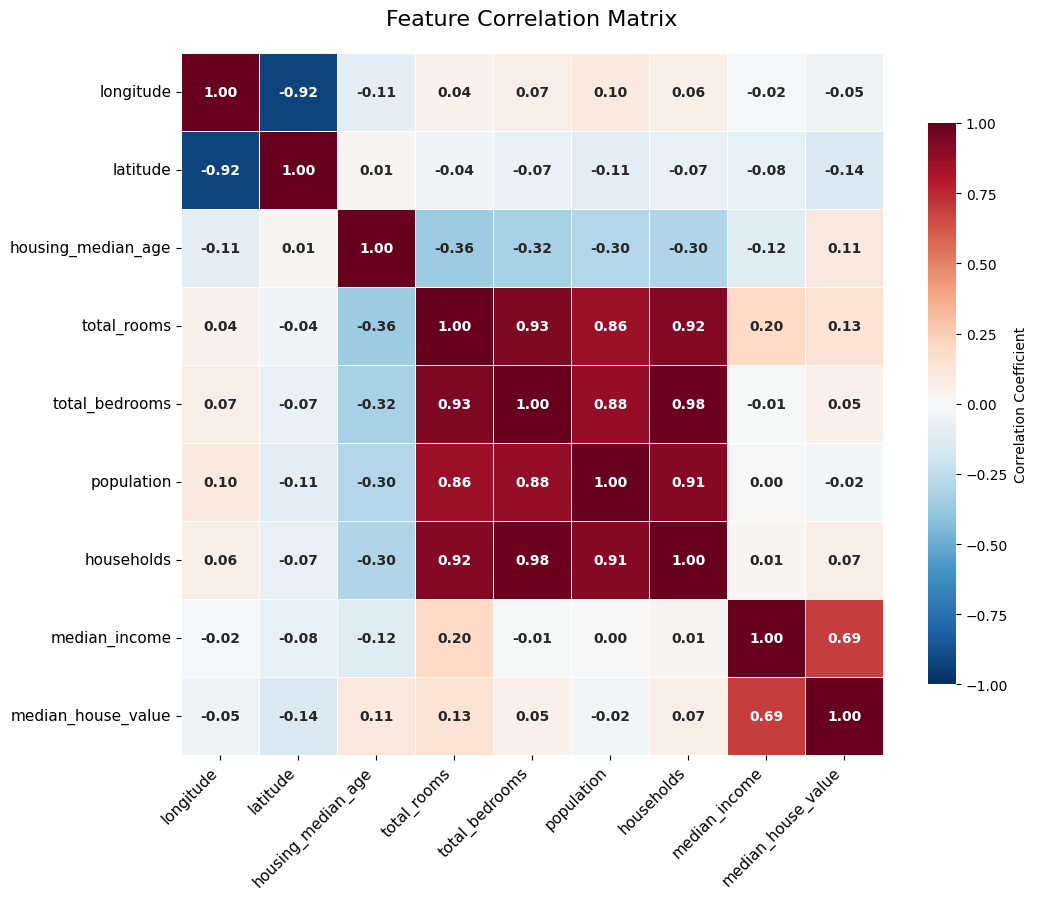

In [44]:
# Correlation heatmap
plt.figure(figsize=(11, 9))

corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix,
            annot=True,              # Show values
            fmt='.2f',               # Format to 2 decimals
            cmap='RdBu_r',           # Red-Blue colormap (reversed)
            center=0,                 # Center at 0
            square=True,              # Square cells
            linewidths=0.5,           # Add lines between cells
            linecolor='white',        # Line color
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},  # Colorbar options
            annot_kws={'size': 10, 'weight': 'bold'},  # Text formatting
            mask=None,                 # No mask
            vmin=-1, vmax=1)           # Set value range

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [57]:
# Scatter plots: top correlated features vs target
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['median_house_value'].drop('median_house_value').sort_values(ascending=True)
correlations.head(10)

latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
Name: median_house_value, dtype: float64

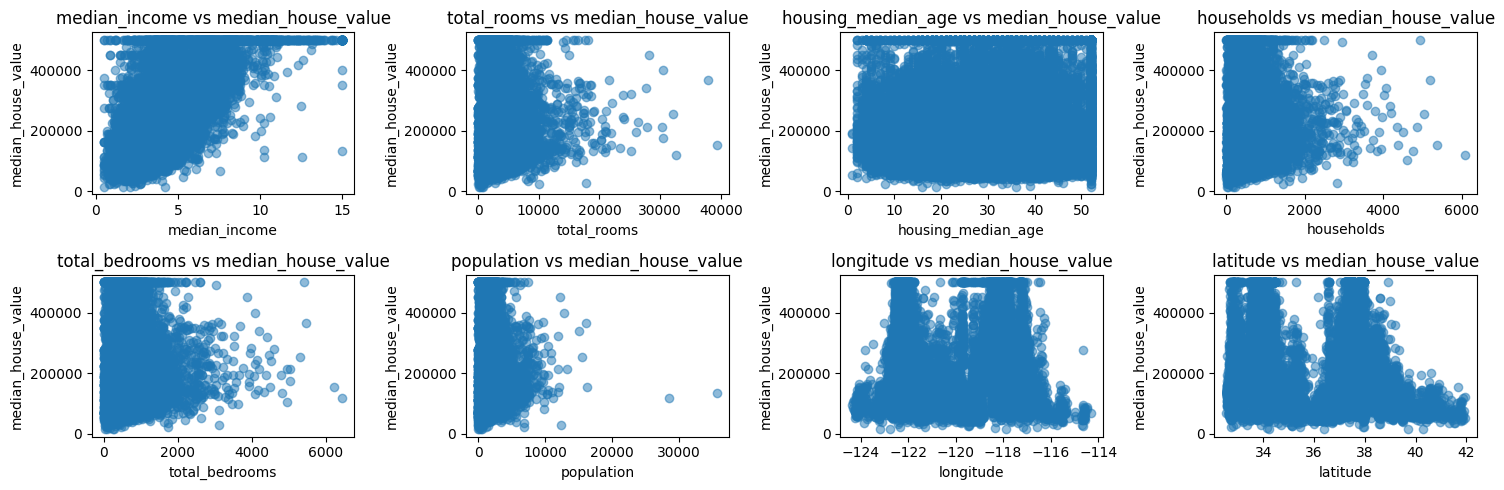

In [8]:
# Create scatter plots
fig, axes = plt.subplots(2, 4, figsize=(15, 5))
for i, feature in enumerate(correlations.index):
    axes.flat[i].scatter(df[feature], df['median_house_value'], alpha=0.5)
    axes.flat[i].set_xlabel(feature)
    axes.flat[i].set_ylabel('median_house_value')
    axes.flat[i].set_title(f'{feature} vs {'median_house_value'}')
plt.tight_layout()
plt.show()

In [ ]:
# Create comprehensive scatter plots for top features
# this is what AI gave me 
'''
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Plot only numeric top features and match number of subplots
features_to_plot = correlations.index[:len(axes)]  # 6 features for 2x3 axes

for i, feature in enumerate(features_to_plot):
    x = numeric_df[feature]
    y = numeric_df['median_house_value']

    # Remove NaN/inf values for stats and fitting
    valid_mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    corr_coef, p_value = stats.pearsonr(x_valid, y_valid)

    axes[i].scatter(x_valid, y_valid, alpha=0.4, s=10, c='steelblue', edgecolors='none')

    z = np.polyfit(x_valid, y_valid, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x_valid.values)
    axes[i].plot(x_sorted, p(x_sorted), "r-", linewidth=2, label=f"Trend (slope={z[0]:.2f})")

    stats_text = f"r = {corr_coef:.3f}\np-value = {p_value:.4f}\nn = {len(x_valid):,}"
    axes[i].text(
        0.05, 0.95, stats_text, transform=axes[i].transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )

    if feature == 'median_income':
        axes[i].set_xlabel('Median Income (tens of thousands)', fontsize=11)
    elif feature == 'housing_median_age':
        axes[i].set_xlabel('Housing Median Age (years)', fontsize=11)
    elif feature in ['total_rooms', 'total_bedrooms', 'population', 'households']:
        axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
        axes[i].set_xscale('log')

    axes[i].set_ylabel('Median House Value ($)', fontsize=11)
    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs House Value\nCorrelation: {corr_coef:.3f}",
        fontsize=12, fontweight='bold'
    )
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].legend(loc='lower right')

plt.suptitle(f'California Housing: Top Features vs Median House Value', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
'''

'\nfig, axes = plt.subplots(2, 3, figsize=(18, 12))\naxes = axes.ravel()\n\n# Plot only numeric top features and match number of subplots\nfeatures_to_plot = correlations.index[:len(axes)]  # 6 features for 2x3 axes\n\nfor i, feature in enumerate(features_to_plot):\n    x = numeric_df[feature]\n    y = numeric_df[\'median_house_value\']\n\n    # Remove NaN/inf values for stats and fitting\n    valid_mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)\n    x_valid = x[valid_mask]\n    y_valid = y[valid_mask]\n\n    corr_coef, p_value = stats.pearsonr(x_valid, y_valid)\n\n    axes[i].scatter(x_valid, y_valid, alpha=0.4, s=10, c=\'steelblue\', edgecolors=\'none\')\n\n    z = np.polyfit(x_valid, y_valid, 1)\n    p = np.poly1d(z)\n    x_sorted = np.sort(x_valid.values)\n    axes[i].plot(x_sorted, p(x_sorted), "r-", linewidth=2, label=f"Trend (slope={z[0]:.2f})")\n\n    stats_text = f"r = {corr_coef:.3f}\np-value = {p_value:.4f}\nn = {len(x_valid):,}"\n    axes[i].text(\n        0

In [10]:
# Missing values summary
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


<Axes: ylabel='Frequency'>

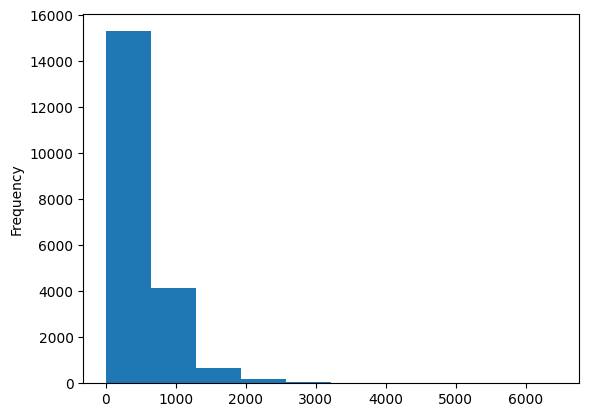

In [11]:
df['total_bedrooms'].plot(kind='hist')

<Axes: xlabel='ocean_proximity'>

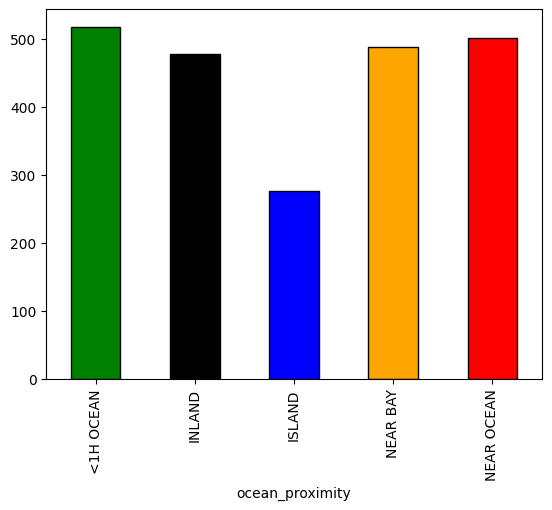

In [12]:
df.groupby('ocean_proximity')['households'].mean().plot(kind='bar', color=['green','black','blue', 'orange', 'red'], edgecolor='black')


<Axes: xlabel='ocean_proximity'>

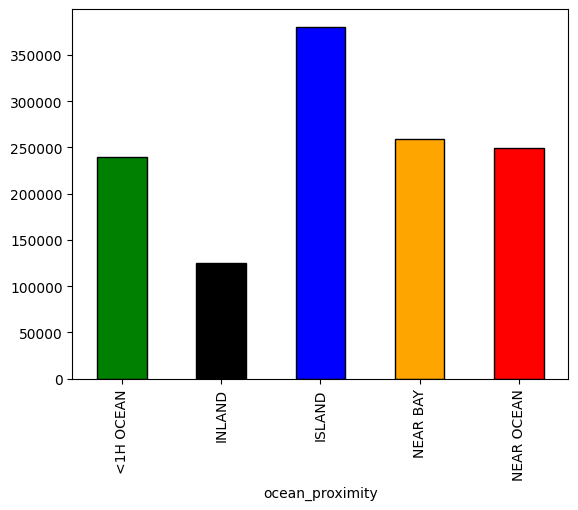

In [13]:
df.groupby('ocean_proximity')['median_house_value'].mean().plot(kind='bar', color=['green','black','blue', 'orange', 'red'], edgecolor='black')


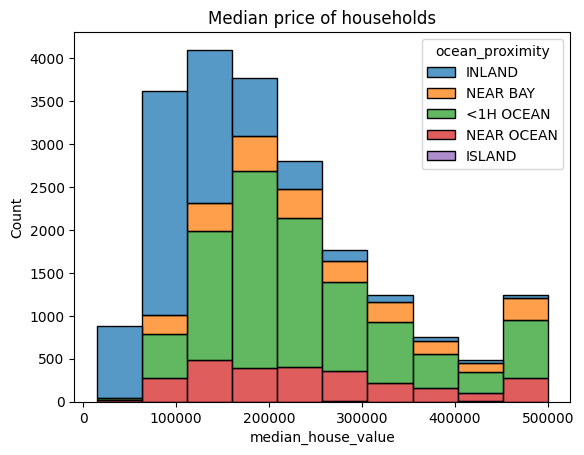

Island houses: are the most expensive
INLAND houses: most parts of them are the cheapest
NEAR BAY houses: they have all the prices
<1H OCEAN houses: they dominate the average
NEAR OCEAN houses: the same as the NEAR BAY


In [30]:
sns.histplot(
    data=df,
    x="median_house_value",
    hue="ocean_proximity",
    bins=10,
    multiple="stack"
)

plt.title("Median price of households")
plt.show()

print("Island houses: are the most expensive")
print("INLAND houses: most parts of them are the cheapest")
print("NEAR BAY houses: they have all the prices")
print("<1H OCEAN houses: they dominate the average")
print("NEAR OCEAN houses: the same as the NEAR BAY")
 

<Axes: xlabel='longitude', ylabel='latitude'>

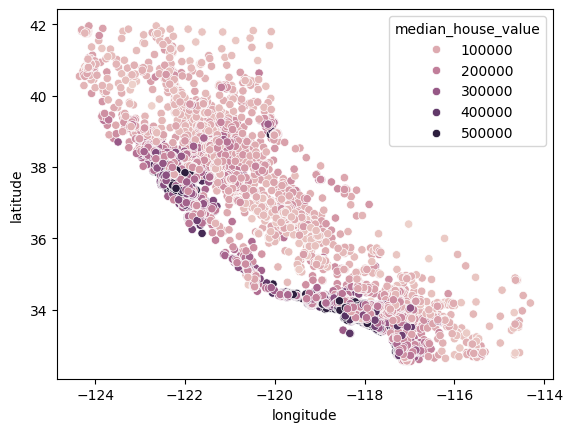

In [56]:
sns.scatterplot(x="longitude", y="latitude", hue="median_house_value", data=df)

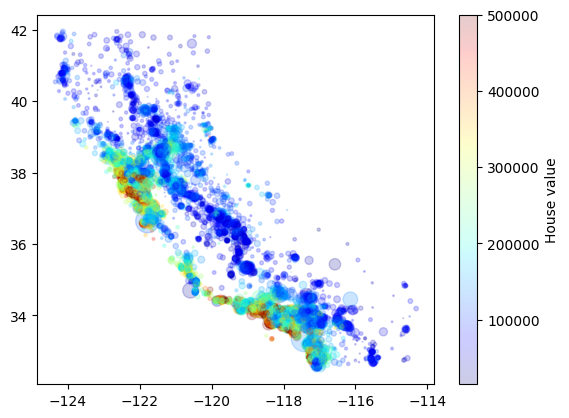

In [53]:
# very interesting !
# option s: radius of each circle represent the population/100
# option c: color represents the median price
#AI <This produces one of the most famous plots in machine learning>
plt.scatter(
df["longitude"],
df["latitude"],
alpha=0.2,
s=df["population"]/100,
c=df["median_house_value"],
cmap="jet")

plt.colorbar(label="House value")

### Initial Hypotheses
1. higher income means higher house value
2. ocean proximity: THE inland houses are cheaper than the one nearest to the ocean
3. 

## Step 3: Data Preparation (45 min) ⏱️

In [15]:
# Handle missing values

In [16]:
# Feature Engineering

In [17]:
# Encoding categorical variables (ocean_proximity)

In [18]:
# Train/Validation split (80/20)

In [19]:
# Feature Scaling

## Step 4: Models FROM SCRATCH (90 min) ⏱️

### Model 1: Linear Regression from Scratch

In [20]:
# Linear Regression from scratch
# Two approaches: Normal Equation (analytical) and Gradient Descent

In [21]:
# Train Linear Regression

### Model 2: KNN Regressor from Scratch

In [22]:
# KNN Regressor from scratch
# Same as KNN classifier but predict = mean of k nearest neighbors (not majority vote)

In [23]:
# Train KNN Regressor

### Model 3: Decision Tree Regressor from Scratch

In [24]:
# Decision Tree Regressor from scratch
# Same structure as classifier but: predict = mean(y) at leaf, split criterion = MSE reduction

In [25]:
# Train Decision Tree Regressor

## Step 5: Evaluation (30 min) ⏱️

In [26]:
# Regression Metrics from scratch: MSE, RMSE, MAE, R²

In [27]:
# Evaluate all 3 models

In [28]:
# Visualize: predicted vs actual scatter plot + residuals

## Step 6: Write-up ⏱️

### Key Findings
1. 
2. 
3. 

### What I'd do with more time
- 

### One thing I learned today
- 

### Where I got stuck
- 

## 🎯 BONUS (if time remains)
- [ ] Polynomial features from scratch
- [ ] Ridge Regression (L2 regularization) from scratch
- [ ] Plot learning curves (train vs val error over training set size)
- [ ] Try log-transforming the target (house prices are right-skewed)
- [ ] Residual analysis: are errors normally distributed?